In [32]:
!pip install -Uq numpy

In [33]:
!pip install -Uq matplotlib

In [34]:
!pip install -Uq pymcel

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc

In [40]:
# Valores aproximados reales (Aten)
sistema = [
    dict(m=1.0, r=np.array([0.0, 0.0, 0.0]), v=np.array([0.0, 0.0, 0.0])), # Sol
    dict(m=3e-6, r=np.array([1.0, 0.0, 0.0]), v=np.array([0.0, 1.0, 0.0])), # Tierra
    dict(m=0.0, r=np.array([0.92, 0, 0]), v=np.array([0, 1.1, 0])) # Apophis real (más rápido por estar más cerca)
]

Se asigna al asteroide una posición inicial ligeramente mayor que la de la Tierra y una velocidad cercana a la velocidad orbital circular, con el fin de generar una órbita elíptica que permita estudiar posibles encuentros cercanos

In [41]:
def aceleraciones(sistema):
    n = len(sistema)
    a = [np.zeros(3) for _ in range(n)]
    
    for i in range(n):
        for j in range(n):
            if i != j:
                r_vec = sistema[j]['r'] - sistema[i]['r']
                dist = np.linalg.norm(r_vec)
                a[i] += sistema[j]['m'] * r_vec / dist**3  # G=1
                
    return a

In [42]:
def paso_leapfrog(sistema, dt):
    
    # 1. Medio paso de velocidad)
    a = aceleraciones(sistema)
    for i in range(len(sistema)):
        sistema[i]['v'] += 0.5 * a[i] * dt

    # 2. Actualizar posición)
    for i in range(len(sistema)):
        sistema[i]['r'] += sistema[i]['v'] * dt

    # Completar velocidad)
    a_new = aceleraciones(sistema)
    for i in range(len(sistema)):
        sistema[i]['v'] += 0.5 * a_new[i] * dt

dt = 0.001
pasos = 20000

trayectorias = [[] for _ in sistema]

for _ in range(pasos):
    paso_leapfrog(sistema, dt)
    
    for i in range(len(sistema)):
        trayectorias[i].append(sistema[i]['r'].copy())

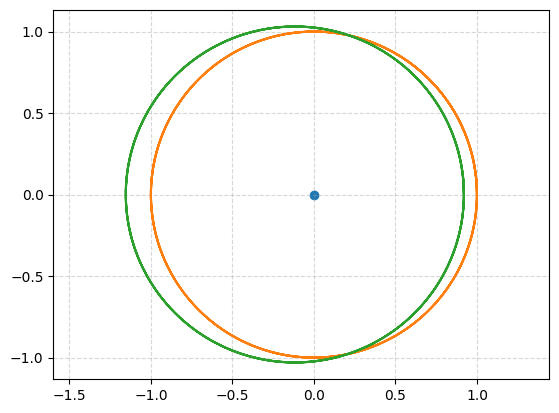

In [44]:
for i in range(len(sistema)):
    tray = np.array(trayectorias[i])
    plt.plot(tray[:,0], tray[:,1])

plt.scatter(0,0)  # Sol
plt.grid(True, linestyle='--', alpha=0.5) 
plt.axis('equal')
plt.show()